── XGBoost ──
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        64
           1       0.90      0.96      0.93       136

    accuracy                           0.91       200
   macro avg       0.91      0.87      0.89       200
weighted avg       0.91      0.91      0.90       200

CV Accuracy : 0.9180 ± 0.0093
CV F1       : 0.9175 ± 0.0096
CV AUC-ROC  : 0.9300 ± 0.0122


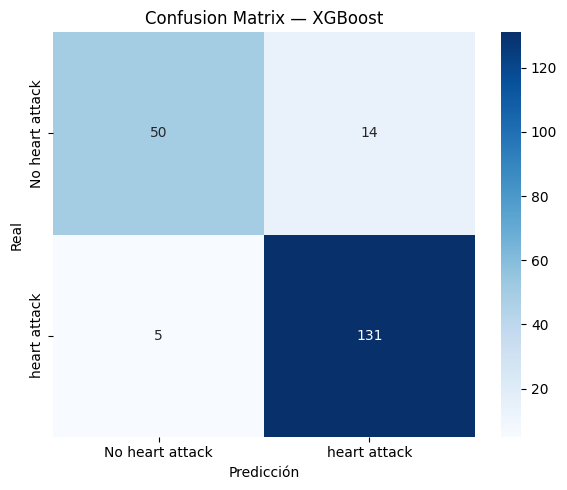

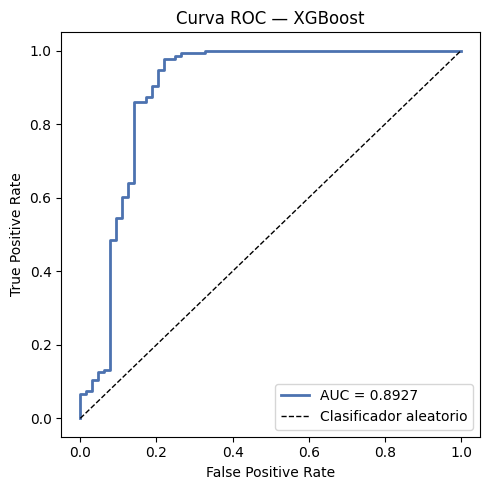


--- 7.1 Importancia global de características ---


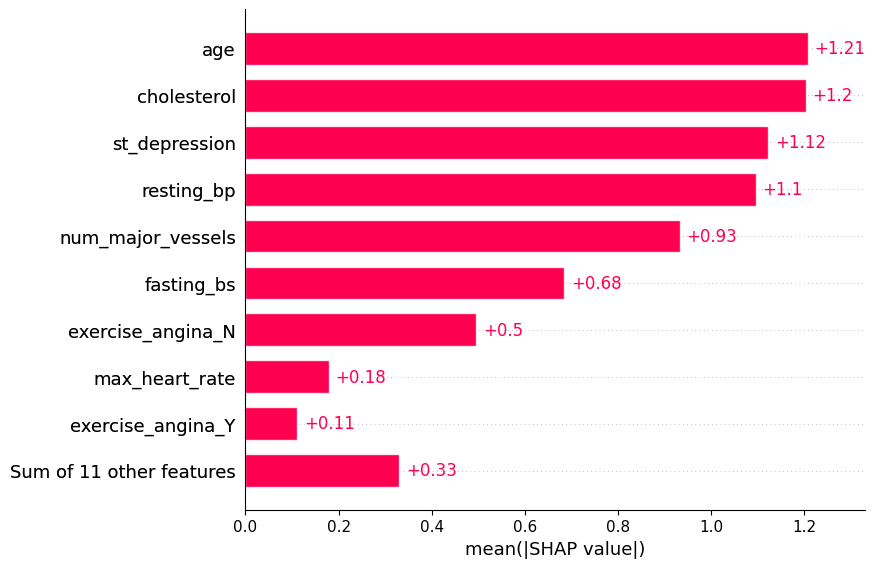


--- 7.2 Distribución y dirección de efectos (beeswarm) ---


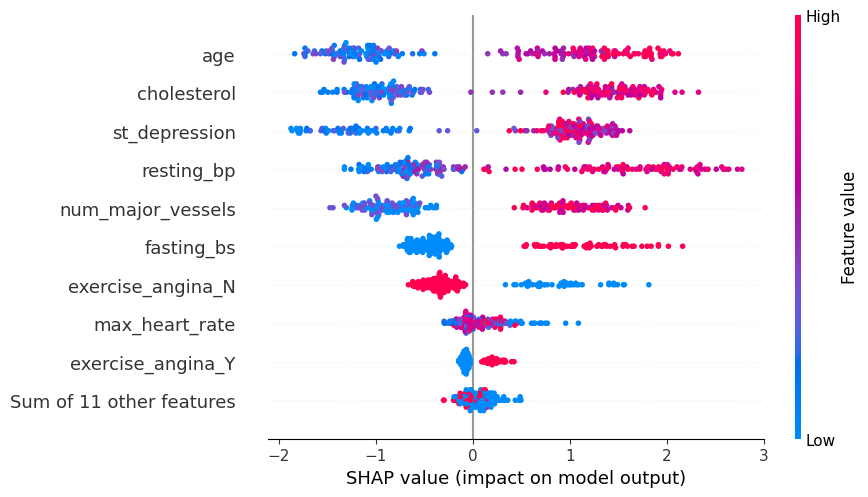


--- 7.3 Explicación del primer paciente (waterfall) ---


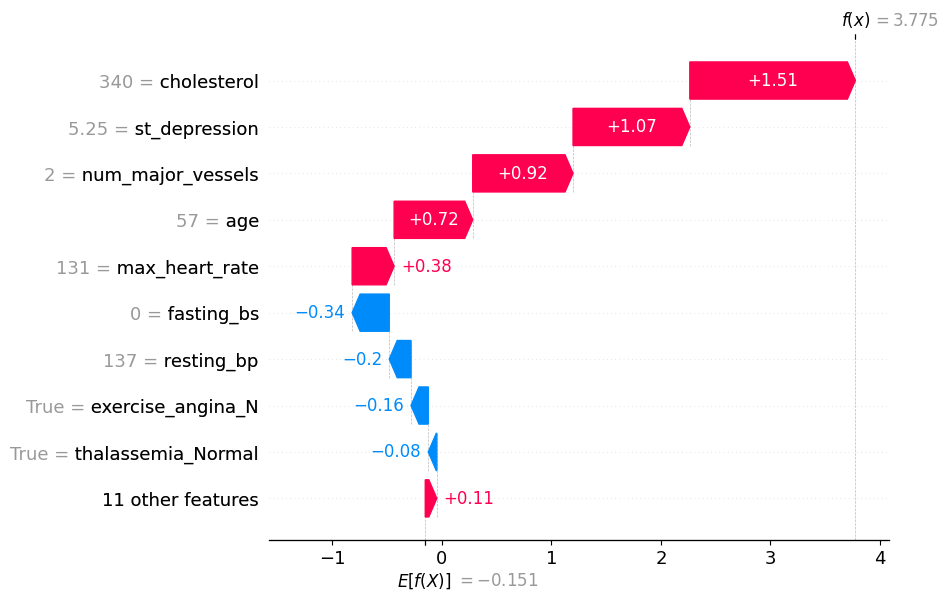


--- 7.4 Heatmap de efectos en todo el subconjunto ---


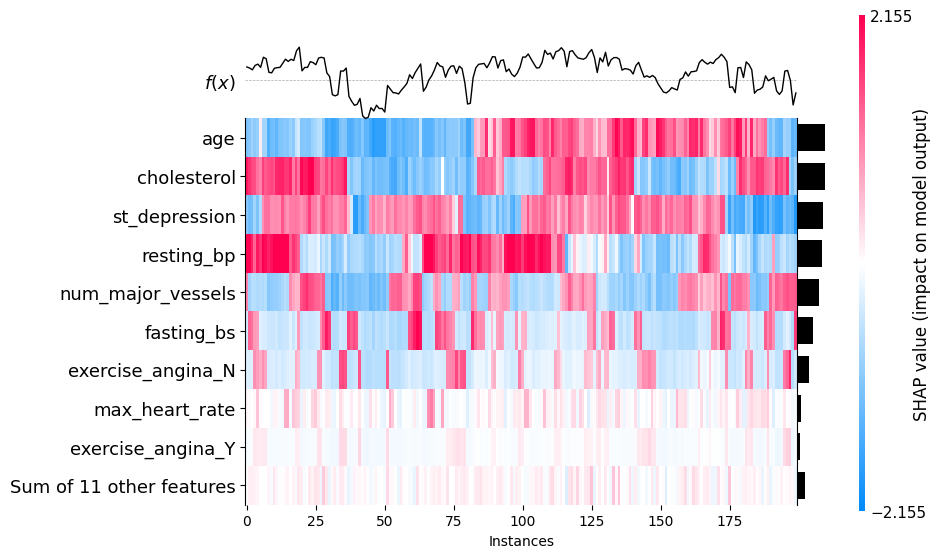

<Axes: xlabel='Instances'>

In [ ]:
import os
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from xgboost import XGBClassifier

# ── Carga de datos
df = pd.read_csv("synthetic_heart_attack_dataset.csv")

df = df.drop(columns=["patient_id"], errors="ignore") # Elimina la columna/s que no se necesitan

df = pd.get_dummies(df, columns=["sex", "ecg_result", "exercise_angina", "slope", "thalassemia"]) # Hace lo mismo Label Encoder

# ── Preprocesamiento
# Se eliminan nulos y duplicados antes de limpiar el texto para evitar errores
df = df.dropna()
df = df.drop_duplicates()

# ── Split
# stratify=y garantiza que cada split mantenga la proporción de clases original
X = df.drop(columns=["heart_attack"])
y = df["heart_attack"]

X.columns = X.columns.str.replace(r"[\[\]<>]", "_", regex=True) # Elimina las caracteres especiales del numbre de las columnas

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Mide el desbalance de clases para que el modelo no ignore la clase minoritaria
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

# ── Modelo
# XGBClassifier para un mejor resultado
modelo = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)

modelo.fit(X_train, y_train) # entrena con el 80% de los datos
pred = modelo.predict(X_test) # predice sobre el 20% restante (datos no vistos)
print("── XGBoost ──")
print(classification_report(y_test, pred))

# Validación cruzada con 5 folds para medir estabilidad del mode
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(modelo, X, y, cv=cv, scoring=("accuracy"))
f1 = cross_val_score(modelo, X, y, cv=cv, scoring=("f1_weighted"))
auc_cv = cross_val_score(modelo, X, y, cv=cv, scoring=("roc_auc"))
print(f"CV Accuracy : {acc.mean():.4f} ± {acc.std():.4f}")
print(f"CV F1       : {f1.mean():.4f} ± {f1.std():.4f}")
print(f"CV AUC-ROC  : {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")

# ── Confusion Matrix
# Muestra cuántas predicciones acertó y falló el modelo por cada categoría
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No heart attack", "heart attack"],
    yticklabels=["No heart attack", "heart attack"]
)
ax.set_title("Confusion Matrix")
ax.set_ylabel("Real")
ax.set_xlabel("Predicción")
plt.tight_layout()
plt.show()
plt.close("all")

# ──── Grafica Curva Roc
# Evalúa qué tan bien separa el modelo las dos clases (infarto vs no infarto)

proba_scores = modelo.predict_proba(X_test)[:, 1] # Probabilidad de pertenecer a la clase positiva (infarto=1)
fpr, tpr, _ = roc_curve(y_test, proba_scores) # FPR = falsas alarmas, TPR = aciertos reales
roc_auc = auc(fpr, tpr) # AUC cercano a 1.0 = modelo casi perfecto; 0.5 = aleatorio

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC = {roc_auc:.4f}") # Curva del modelo
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio") # Línea base de referencia (sin poder predictivo)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC — XGBoost")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
plt.close("all")


# ──── Graficas con Shap
# Cuantifica cuánto contribuye cada variable a la predicción del modelo.
X_sample = X_test[:500].copy()

explainer = shap.TreeExplainer(modelo) # Explainer optimizado para modelos basados en árboles (XGBoost, LightGBM, etc.)
shap_values = explainer(X_sample) # Calcula el valor SHAP de cada feature para cada paciente del subconjunto

print("\n--- 7.1 Importancia global de características ---")
shap.plots.bar(shap_values, max_display=10)

print("\n--- 7.2 Distribución y dirección de efectos (beeswarm) ---")
shap.plots.beeswarm(shap_values, max_display=10)

print("\n--- 7.3 Explicación del primer paciente (waterfall) ---")
shap.plots.waterfall(shap_values[0], max_display=10)

print("\n--- 7.4 Heatmap de efectos en todo el subconjunto ---")
shap.plots.heatmap(shap_values)